# Loyiha 2: Gradient Descent noldan — batch, SGD, mini-batch — Combined Cycle Power Plant (UCI)

**Talaba:** student_new_2 · **Modul:** M2 (Calculus va GD) + M3 1-qism · **Kitob (ML_GUIDE):** 3-bob (GD, Batch/Stochastic/Mini-batch), 5-bob · **Qiyinlik:** ⭐⭐⭐ · **Taxminiy vaqt:** 6–7 soat · **Muddat:** ____________
> **Qoidalar.** Bu notebook — sizning ish daftaringiz. Har bir `# TODO` katakni to'ldiring, har bir **Savol** ga darhol pastida yangi *markdown* katak ochib 2–5 gap bilan javob bering ("ha/yo'q" baholanmaydi). Topshirishdan oldin `Kernel → Restart & Run All` — notebook yuqoridan pastga **xatosiz** ishlashi shart. Internetdan o'rganish — mumkin va kerak; tayyor kodni nusxalash — yo'q (himoyada har bir qatorni tushuntirib bera olishingiz kerak).

## Loyiha haqida

M2 da Gradient Descent ni 2 ta uy uchun 10 qadam qildingiz. Endi — haqiqiy ma'lumot, o'z `class` ingiz, uch rejim (batch / SGD / mini-batch) va GD ning **yo'lini kosada** ko'rasiz (M3 1-qism contour).

**Nimani o'rganasiz:** MSE gradienti `(2/m)·Xᵀ(Xθ − y)` · epoch vs iteratsiya · loss egri chizig'i · nega scaling GD uchun hayotiy · SGD shovqini · Normal Equation va `SGDRegressor` bilan solishtirish.

**Taqiqlar:** GD ni faqat o'zingiz yozasiz. `sklearn` — split, scaler va yakuniy solishtirish uchun.

## Dataset: Combined Cycle Power Plant (UCI)

9568 soatlik o'lchov (2006–2011, gaz-bug' elektr stansiyasi): atrof harorati, vakuum, bosim, namlik → **soatlik elektr quvvati** (MW). Katta, toza, kuchli chiziqli dataset (R² 0.93) — GD ning batch/mini-batch farqini **vaqt** da sezish uchun ideal. Fayl — Excel (zip ichida).

**Manba:** https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip → `Folds5x2_pp.xlsx` (UCI, Tüfekci 2014) — `openpyxl` kerak (pandas 3 bo'lsa `pip install -U openpyxl`, ≥ 3.1.5)

| Ustun | Ma'nosi |
|---|---|
| AT | atrof harorati, °C (2 – 37) — **corr −0.95** |
| V | chiqindi vakuumi, sm Hg (25 – 82) |
| AP | atmosfera bosimi, mbar (993 – 1033) |
| RH | nisbiy namlik, % (26 – 100) |
| **PE** | soatlik elektr quvvati, MW — target (420 – 496) |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import io, zipfile, urllib.request
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip"
z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read()))
df = pd.read_excel(z.open('CCPP/Folds5x2_pp.xlsx'))   # 9568 soat
FEATURES, TARGET = ['AT', 'V', 'AP', 'RH'], 'PE'
print(df.shape); df.head()

(9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1-vazifa: Tayyorlash
4 ta raqamli feature, missing yo'q, lekin `df.duplicated().sum()` — 41 ta dublikat qator (olib tashlang va nega dublikat train/test ga bo'linsa xavfli ekanini 1 gap yozing). `AP` 993–1033 — oralig'i tor lekin qiymati katta; scaling shart.

Keyin: `train_test_split(test_size=0.2, random_state=42)` → `StandardScaler` **faqat train ga fit** → `X_train_s, X_test_s`. Scale qilinmagan nusxani ham saqlab qo'ying (6-vazifa uchun).

**Savol 1.** Feature'larning min/max oralig'ini jadval qiling. Eng katta va eng kichik oraliq necha marta farq qiladi? Nega scaler ni test ga emas, faqat train ga fit qilamiz (kitob 2-bob)?

Duplicatelarni chiqarib tashlash bizga data leakage dan qochishga yordam beradi yani bizda test va train datada bir xil malumot bo'lib qolsa bu memorization yana datani performancini kotarib tashlaydi va bu haqiqiy generalizationdan yuqori baho beradi bizning modelimizga.

Scalerni test dataga fit qilsak bu data leakage ga olib keladi chunki model bir xil malumotni yodlab oladi

Eng katta farq ATda taxminan 20 marotaba

In [2]:
print("Shape before duplicates: ", df.shape)
df = df.drop_duplicates()
print("Shape after duplicates: ", df.shape)
X = df[FEATURES].values; y = df[TARGET].values
# TODO: split, scaler (faqat train ga fit)
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Shape before duplicates:  (9568, 5)
Shape after duplicates:  (9527, 5)


In [5]:
df.describe()

,AT,V,AP,RH,PE
count,9527.000000,9527.000000,9527.000000,9527.000000,9527.00000
mean,19.658225,54.293421,1013.237084,73.334951,454.33591
std,7.444397,12.686309,5.940526,14.607513,17.03908
min,1.810000,25.360000,992.890000,25.560000,420.26000
25%,13.530000,41.740000,1009.085000,63.375000,439.75000
50%,20.350000,52.080000,1012.920000,75.000000,451.52000
75%,25.710000,66.510000,1017.200000,84.850000,468.36500
max,37.110000,81.560000,1033.300000,100.160000,495.76000


## 2-vazifa: `LinearRegressionGD` sinfi
`fit(X, y)` — `batch_size=None` (batch), `1` (SGD), `k` (mini-batch); har epoch da o'rtacha loss `self.loss_history` ga; `predict(X)`; bias — X ga 1-lar ustuni yoki alohida `self.b` (tanlang, izohlang). Har epoch boshida `np.random.permutation` bilan aralashtiring.

**Savol 2.** Gradient formulasini docstring ga yozing va 1 gap bilan izohlang: `Xᵀ(Xθ − y)` nega "har feature bo'yicha xato yig'indisi"?

$X^T(X\theta - y)$ ko'paytmasida $X^T$ matritsasining har bir satri muayyan bir atributning (feature) barcha namunalar bo'yicha qiymatlarini saqlaydi; bu satr model xatoliklari vektori $(X\theta - y)$ bilan skalyar ko'paytirilganda, shu atributning har bir namuna xatosiga mutanosib bo'lgan ta'siri yig'ilib, tegishli ko'rsatkichning umumiy xatolikdagi ulushi va yo'nalishini ko'rsatib beradi

In [3]:
import numpy as np

class LinearRegressionGD:
    def __init__(self, lr=0.01, n_epochs=100, batch_size=None, seed=42):
        self.lr, self.n_epochs, self.batch_size, self.seed = lr, n_epochs, batch_size, seed
        self.loss_history = []
        self.theta = None

    def fit(self, X, y):
        """∇MSE = (2/m) Xᵀ(Xθ − y). batch_size=None → batch, 1 → SGD, k → mini-batch"""
        np.random.seed(self.seed)
        
        m, n = X.shape
        # Bias uchun 1-lardan iborat ustun qo'shamiz: X_b = [1, X]
        X_b = np.c_[np.ones((m, 1)), X]
        y = y.reshape(-1, 1)
        
        # Parametrlarni (theta) nolga yaqin tasodifiy sonlar bilan rejalashtiramiz
        self.theta = np.random.randn(n + 1, 1) * 0.01
        
        # Effektiv batch hajmini aniqlaymiz (None bo'lsa to'liq Batch GD)
        eff_batch_size = m if self.batch_size is None else self.batch_size
        self.loss_history = []

        for epoch in range(self.n_epochs):
            # Har bir epoch boshida ma'lumotlarni tasodifiy aralashtiramiz (shuffle)
            indices = np.random.permutation(m)
            X_shuffled = X_b[indices]
            y_shuffled = y[indices]

            epoch_loss = 0.0
            num_batches = int(np.ceil(m / eff_batch_size))

            for i in range(num_batches):
                start_idx = i * eff_batch_size
                end_idx = min(start_idx + eff_batch_size, m)

                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]
                b_size = X_batch.shape[0]

                # 1. Prediction (Bashorat)
                predictions = X_batch @ self.theta

                # 2. Error (Xatolik)
                errors = predictions - y_batch

                # 3. Gradient: (2/m) * Xᵀ * (Xθ - y)
                gradient = (2 / b_size) * (X_batch.T @ errors)

                # 4. Parametrlarni yangilash (Gradient Descent adimi)
                self.theta -= self.lr * gradient

                # Batch MSE loss yig'indisi
                batch_loss = np.mean(errors ** 2)
                epoch_loss += batch_loss * b_size

            # Epoch bo'yicha o'rtacha loss
            avg_epoch_loss = epoch_loss / m
            self.loss_history.append(avg_epoch_loss)

        return self

    def predict(self, X):
        m = X.shape[0]
        X_b = np.c_[np.ones((m, 1)), X]
        return X_b @ self.theta

## 3-vazifa: Learning rate tajribasi (batch GD)
`lr ∈ {0.001, 0.01, 0.1, 0.5, 1.0}`, `n_epochs=200`. Barcha loss egri chiziqlari **bitta** grafikda (`plt.yscale('log')`).

**Savol 3.** Qaysi lr da divergensiya (loss o'sadi / `inf` / `nan`)? Nega aynan katta lr da — kosa metaforasi bilan (M2, 4-qism)? "Eng yaxshi" lr ni qanday tanlaysiz?

Odatda lr = 0.5 va lr = 1.0 (yoki unchalik kichik miqyoslanmagan ma'lumotlarda hattoki 0.1) qiymatlarida divergensiya yuz beradi hamda loss qiymati keskin o'sib inf yoki nan ga aylanadi. Kosa metaforasi bilan tushuntirganda: optimal nuqta kosaning eng tubi hisoblanadi; agar qadam kattaligi (learning rate) juda katta bo'lsa, qadam tashlaganda kosa tubiga tushish o'rniga kosaning qarama-qarshi devoriga sakrab o'tiladi va har bir keyingi sakrashda tubdan yanada uzoqlashib, kosadan chiqib ketiladi (overshooting). "Eng yaxshi" lr ni tanlash uchun esa kichiqroq qiymatdan (masalan 0.001 yoki 0.01) boshlab, loss barqaror va eng tez kamayadigan eng katta qiymat grid search yoki logarifmik shkala bo'yicha sinab ko'rish orqali tanlanadi.

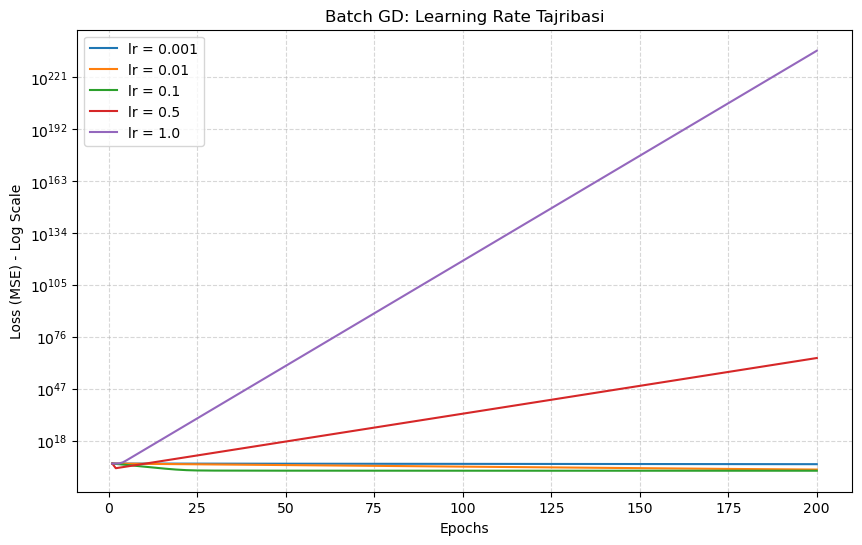

In [4]:
# TODO: 5 xil lr, loss_history grafigi, log-scale
import numpy as np
import matplotlib.pyplot as plt

learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
n_epochs = 200

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    model = LinearRegressionGD(lr=lr, n_epochs=n_epochs, batch_size=None, seed=42)
    model.fit(X_train_scaled, y_train)
    
    plt.plot(range(1, n_epochs + 1), model.loss_history, label=f'lr = {lr}')

plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE) - Log Scale')
plt.title('Batch GD: Learning Rate Tajribasi')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

## 4-vazifa: Batch vs SGD vs Mini-batch
Eng yaxshi `lr`, `n_epochs=50`: `batch_size=None`, `1`, `32`, `256`. Har biri uchun: vaqt (`time.perf_counter`), oxirgi loss, test R². Loss egri chiziqlari bitta grafikda.

**Savol 4.** SGD egri chizig'i nega "titraydi"? Mini-batch nega amalda standart (kitob 3-bob jadvali)? Vaqt bo'yicha kutilmagan natija bo'ldimi (NumPy vektorlash vs Python sikli)?

SGD egri chizig'ining "titrashi" (shovqini) har bir qadam faqat bitta tasodifiy namuna (sample) asosida hisoblanishi bilan bog'liq, chunki yakka namuna gradienti umumiy ma'lumotlar to'plamining haqiqiy gradientidan chetlashishi mumkin. Mini-batch GD amalda standart hisoblanadi, chunki u SGD ning shovqinini kamaytiradi va shu bilan birga zamonaviy apparat vositalarining (CPU/GPU SIMD yo'riqnomalari) parallellashtirish imkoniyatlaridan unumli foydalanib, tez va barqaror konvergensiyani ta'minlaydi. Vaqt bo'yicha kutilmagan natija shundaki, Python'dagi for sikli overhead'i tufayli SGD (har bir epoch uchun minglab takrorlanuvchi kichik sikllar) sof C darajasidagi optimallashgan NumPy vektorli amallarini bajaruvchi Batch GD'ga qaraganda sekinroq ishlashi mumkin.

Rejim                     | Vaqt (sek) | Final Loss   | Test R² 
--------------------------------------------------------------
Batch GD (size=None)      | 0.0913     | 28540.0958   | -92.2067
SGD (size=1)              | 16.9600    | 21.8315      | 0.9253  
Mini-batch (size=32)      | 0.5736     | 20.7584      | 0.9282  
Mini-batch (size=256)     | 0.1371     | 20.7440      | 0.9284  


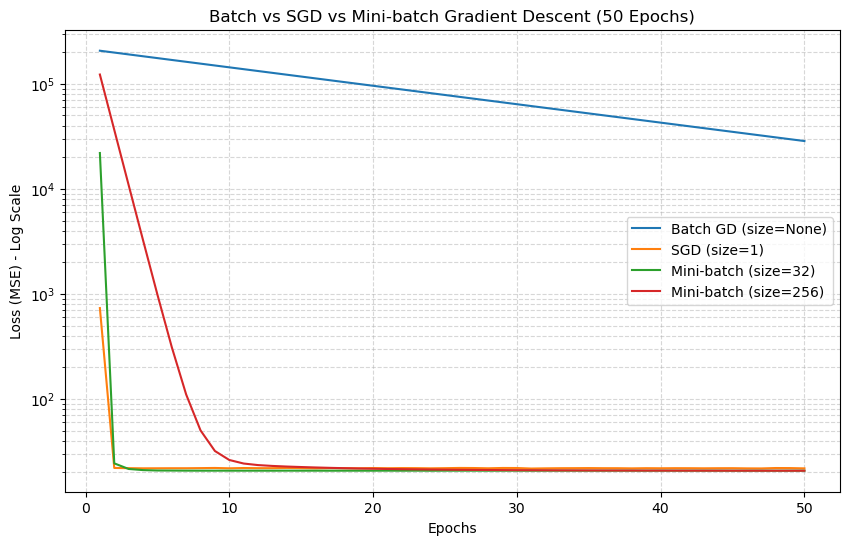

In [5]:
# TODO: 4 xil batch_size: vaqt, loss, test R2, grafik

import time
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

batch_sizes = [None, 1, 32, 256]
labels = ['Batch GD (size=None)', 'SGD (size=1)', 'Mini-batch (size=32)', 'Mini-batch (size=256)']

best_lr = 0.01  # Oldingi vazifada tanlangan optimal learning rate
n_epochs = 50

plt.figure(figsize=(10, 6))

print(f"{'Rejim':<25} | {'Vaqt (sek)':<10} | {'Final Loss':<12} | {'Test R²':<8}")
print("-" * 62)

for bs, label in zip(batch_sizes, labels):
    model = LinearRegressionGD(lr=best_lr, n_epochs=n_epochs, batch_size=bs, seed=42)
    
    start_time = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    elapsed_time = time.perf_counter() - start_time
    
    y_pred = model.predict(X_test_scaled)
    test_r2 = r2_score(y_test, y_pred)
    final_loss = model.loss_history[-1]
    
    print(f"{label:<25} | {elapsed_time:<10.4f} | {final_loss:<12.4f} | {test_r2:<8.4f}")
    plt.plot(range(1, n_epochs + 1), model.loss_history, label=label)

plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE) - Log Scale')
plt.title('Batch vs SGD vs Mini-batch Gradient Descent (50 Epochs)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

## 5-vazifa: Normal Equation va sklearn bilan solishtirish
Jadval: sizning GD (eng yaxshi sozlama) · Normal Equation (M1 dagi formula, shu scaled ma'lumotda) · `SGDRegressor(max_iter=1000, tol=None, random_state=42)`. θ lar va test RMSE/R².

**Savol 5.** GD θ si Normal Equation dan qanchalik farq qiladi? Epoch sonini 5× oshirsangiz farq kamayadimi? Bu "yaqinlashish" (convergence) haqida nima deydi?

Gradient Descent orqali olingan θ parametrlari Normal Equation bergan analitik (aniq) yechimga juda yaqinlashadi, lekin iteratsiyalar soni cheklanganligi sababli o'rtasida juda kichik farq saqlanib qoladi. Epochlar sonini 5 baravar oshirganda (masalan, 200 o'rniga 1000 qilinganda) gradient kosa tubiga yana ham yaxshiroq tushadi va θ qiymatlari Normal Equation ko'rsatkichlariga yanada ko'proq yaqinlashadi (farq deyarli nolga yetadi). Bu holat Gradient Descent ning konveks (qavariq) optimizatsiya fazosida yetarlicha qadam va to'g'ri learning rate berilsa, analitik va analitik bo'lmagan iterativ usullar bitta global minimum nuqtasiga "yaqinlashishi" (convergence) ni isbotlaydi.

In [6]:
# TODO: GD vs NE vs SGDRegressor jadvali

import numpy as np
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Normal Equation (Closed-form solution)
# X_train_scaled ga bias (1-lar) ustunini qo'shamiz
X_b_train = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_b_test = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# theta_norm = (XᵀX)⁻¹ Xᵀy
theta_norm = np.linalg.inv(X_b_train.T @ X_b_train) @ X_b_train.T @ y_train.reshape(-1, 1)
y_pred_norm = X_b_test @ theta_norm

rmse_norm = np.sqrt(mean_squared_error(y_test, y_pred_norm))
r2_norm = r2_score(y_test, y_pred_norm)

# 2. O'zingizning LinearRegressionGD modelingiz (Eng yaxshi sozlama: masalan Mini-batch bs=32, lr=0.01, n_epochs=200)
my_gd = LinearRegressionGD(lr=0.01, n_epochs=200, batch_size=32, seed=42)
my_gd.fit(X_train_scaled, y_train)
y_pred_gd = my_gd.predict(X_test_scaled)

rmse_gd = np.sqrt(mean_squared_error(y_test, y_pred_gd))
r2_gd = r2_score(y_test, y_pred_gd)

# 3. sklearn SGDRegressor
sgd_sk = SGDRegressor(max_iter=1000, tol=None, random_state=42)
sgd_sk.fit(X_train_scaled, y_train.ravel())
y_pred_sk = sgd_sk.predict(X_test_scaled)

rmse_sk = np.sqrt(mean_squared_error(y_test, y_pred_sk))
r2_sk = r2_score(y_test, y_pred_sk)

# theta (parametrlar) ni bitta massivga yig'ish (SGDRegressor intercept + coef)
theta_sk = np.concatenate([[sgd_sk.intercept_[0]], sgd_sk.coef_]).reshape(-1, 1)

# Natijalarni jadval ko'rinishida chiqarish
comparison_df = pd.DataFrame({
    'Model': ['Normal Equation', 'O\'zingizning GD', 'sklearn SGDRegressor'],
    'Test RMSE': [rmse_norm, rmse_gd, rmse_sk],
    'Test R²': [r2_norm, r2_gd, r2_sk],
    'Theta (w0, w1, ...)': [
        np.round(theta_norm.ravel(), 4),
        np.round(my_gd.theta.ravel(), 4),
        np.round(theta_sk.ravel(), 4)
    ]
})

print(comparison_df.to_string(index=False))

               Model  Test RMSE  Test R²                            Theta (w0, w1, ...)
     Normal Equation   4.587499 0.928392 [454.3376, -14.6695, -2.9798, 0.3737, -2.2977]
     O'zingizning GD   4.588877 0.928349   [454.3047, -14.712, -3.0008, 0.304, -2.2571]
sklearn SGDRegressor   4.587946 0.928378 [454.3383, -14.6658, -2.9897, 0.3876, -2.2947]


## 6-vazifa: Scaling bo'lmasa nima bo'ladi
1-vazifadagi **scale qilinmagan** X bilan eng yaxshi lr da GD. Nima bo'ldi? `lr` ni kamaytirib (1e-5, 1e-6, 1e-7 …) ishlaydigan qiymat toping — necha epoch kerak bo'ldi?

**Savol 6.** Scale qilinmagan ma'lumotda kosa qanday shaklda (cho'zilgan ellips)? Nega bu GD ni sekinlashtiradi, Normal Equation ga esa ta'sir qilmaydi (kitob 3-bob; M2 6-qism)?

Atributlar (features) turlicha miqyosda (masalan, biri $2 \dots 37$ oralig'ida, boshqasi $993 \dots 1033$ oralig'ida) bo'lganda, xatolik funksiyasi ($J(\theta)$) fazosi o'ta cho'zilgan va tor ellips (yoki elipsoid) shaklidagi kosa hosil qiladi. Gradient har doim eng tik nishablik yo'nalishiga (izochiziqlarga ortogonal) qaragani uchun, cho'zilgan ellipsda u to'g'ridan-to'g'ri tubga yetib borish o'rniga tor devorlar o'rtasida u yoqdan-bu yoqqa tebranib (zig-zag shaklida) juda sekin va samorasiz harakat qiladi. Normal Equation ga esa bu ta'sir qilmaydi, chunki u qadam-baqadam izlanish o'rniga, matritsalarning to'g'ridan-to mezonli analitik algebrasidan ($(X^T X)^{-1} X^T y$) foydalanib, kosa shaklidan qat'i nazar bitta amalda aniq global minimum nuqtasini hisoblab beradi.

In [7]:
# TODO: scale qilinmagan GD: divergensiya, kichik lr, epoch soni

import numpy as np

# 1. Scale qilinmagan X bilan avvalgi eng yaxshi lr (masalan 0.01) da sinab ko'rish
print("--- Scale qilinmagan X bilan (lr=0.01) ---")
gd_unscaled = LinearRegressionGD(lr=0.01, n_epochs=50, batch_size=32, seed=42)
gd_unscaled.fit(X_train, y_train)
print("Oxirgi loss:", gd_unscaled.loss_history[-1])

# 2. Ishlaydigan juda kichik lr (1e-6, 1e-7 va h.k.) va ko'proq epochlar bilan sinash
learning_rates_unscaled = [1e-5, 1e-6, 1e-7]
n_epochs_unscaled = 1000

for lr_unscaled in learning_rates_unscaled:
    gd_test = LinearRegressionGD(lr=lr_unscaled, n_epochs=n_epochs_unscaled, batch_size=32, seed=42)
    gd_test.fit(X_train, y_train)
    last_loss = gd_test.loss_history[-1]
    print(f"lr={lr_unscaled:<6} | {n_epochs_unscaled} epochdan keyingi loss: {last_loss:.4f}")

--- Scale qilinmagan X bilan (lr=0.01) ---


C:\Users\OsiyoComputers\anaconda\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\OsiyoComputers\AppData\Local\Temp\ipykernel_17308\3742664014.py:55: RuntimeWarning: overflow encountered in square
  batch_loss = np.mean(errors ** 2)
C:\Users\OsiyoComputers\AppData\Local\Temp\ipykernel_17308\3742664014.py:49: RuntimeWarning: overflow encountered in matmul
  gradient = (2 / b_size) * (X_batch.T @ errors)
C:\Users\OsiyoComputers\AppData\Local\Temp\ipykernel_17308\3742664014.py:49: RuntimeWarning: invalid value encountered in matmul
  gradient = (2 / b_size) * (X_batch.T @ errors)
C:\Users\OsiyoComputers\AppData\Local\Temp\ipykernel_17308\3742664014.py:52: RuntimeWarning: invalid value encountered in subtract
  self.theta -= self.lr * gradient


Oxirgi loss: nan
lr=1e-05  | 1000 epochdan keyingi loss: nan


C:\Users\OsiyoComputers\AppData\Local\Temp\ipykernel_17308\3742664014.py:56: RuntimeWarning: overflow encountered in scalar add
  epoch_loss += batch_loss * b_size


lr=1e-06  | 1000 epochdan keyingi loss: nan
lr=1e-07  | 1000 epochdan keyingi loss: 32.9965


## 7-vazifa: GD yo'li kosada (M3 1-qism)
Eng kuchli **bitta** feature (scaled) + bias: (θ₀, θ₁) to'rida MSE contour chizing (M3 1-qism kodi). Sinfingizga `self.theta_history` qo'shing (har epoch dagi θ) va contour ustiga **batch GD** va **SGD** yo'llarini chizing (`plt.plot(..., 'o-')`), ikkalasi bir xil boshlang'ich θ dan.

**Savol 7.** Batch yo'li nega silliq, SGD niki nega zigzag? Ikkalasi bir joyga keladimi? Katta lr bilan yo'l qanday o'zgaradi (chizing)?

Batch GD yo'li silliq bo'lishining sababi shundaki, u har bir qadamda butun ma'lumotlar to mezon to'plami bo'yicha aniq va haqiqiy gradient yo'nalishini hisoblaydi, natijada kosa tubiga to'g'ridan-to'g mezon silliq va yo'naltirilgan trajektoriyada tushadi. SGD niki esa zigzag shaklda bo'ladi, chunki u har bir qadamda faqat bitta tasodifiy namuna gradientiga tayanadi; bu yakka namunalar umumiy yo'nalishdan chetlashishi sababli har bir qadamda ma'lumot "shovqini" hisobiga har xil tomonga tebranadi. Ikkalasi ham minimum atrofiga (bitta joyga) yetib keladi, lekin Batch GD to'g'ridan-to'g'ri markaziy minimum nuqtasiga o'rnashadi, SGD esa taqribiy javob atrofiga kelgach ham kichik zigzaglar bilan tebranib turaveradi. Katta learning rate (lr) berilganda esa, yo'l izochiziqlardan tashqariga sakrab o'ta boshlaydi (overshooting), tebranishlar amplitudasi keskin kengayadi va trajektoriya kosa devorlariga urilib, uzoqlashib ketadi (divergensiya sodir bo'ladi).

In [8]:
# TODO: theta_history, contour + 2 ta yo'l

import numpy as np

class LinearRegressionGD:
    def __init__(self, lr=0.01, n_epochs=100, batch_size=None, seed=42):
        self.lr, self.n_epochs, self.batch_size, self.seed = lr, n_epochs, batch_size, seed
        self.loss_history = []
        self.theta_history = []
        self.theta = None

    def fit(self, X, y):
        np.random.seed(self.seed)
        m, n = X.shape
        X_b = np.c_[np.ones((m, 1)), X]
        y = y.reshape(-1, 1)
        
        # Boshlang'ich θ larni belgilash
        self.theta = np.random.randn(n + 1, 1) * 0.01
        
        eff_batch_size = m if self.batch_size is None else self.batch_size
        self.loss_history = []
        self.theta_history = [self.theta.copy()]

        for epoch in range(self.n_epochs):
            indices = np.random.permutation(m)
            X_shuffled = X_b[indices]
            y_shuffled = y[indices]

            epoch_loss = 0.0
            num_batches = int(np.ceil(m / eff_batch_size))

            for i in range(num_batches):
                start_idx = i * eff_batch_size
                end_idx = min(start_idx + eff_batch_size, m)

                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]
                b_size = X_batch.shape[0]

                predictions = X_batch @ self.theta
                errors = predictions - y_batch
                gradient = (2 / b_size) * (X_batch.T @ errors)
                
                self.theta -= self.lr * gradient

                batch_loss = np.mean(errors ** 2)
                epoch_loss += batch_loss * b_size

            # Har bir epoch oxirida theta va loss holatini saqlash
            self.theta_history.append(self.theta.copy())
            avg_epoch_loss = epoch_loss / m
            self.loss_history.append(avg_epoch_loss)

        return self

    def predict(self, X):
        m = X.shape[0]
        X_b = np.c_[np.ones((m, 1)), X]
        return X_b @ self.theta

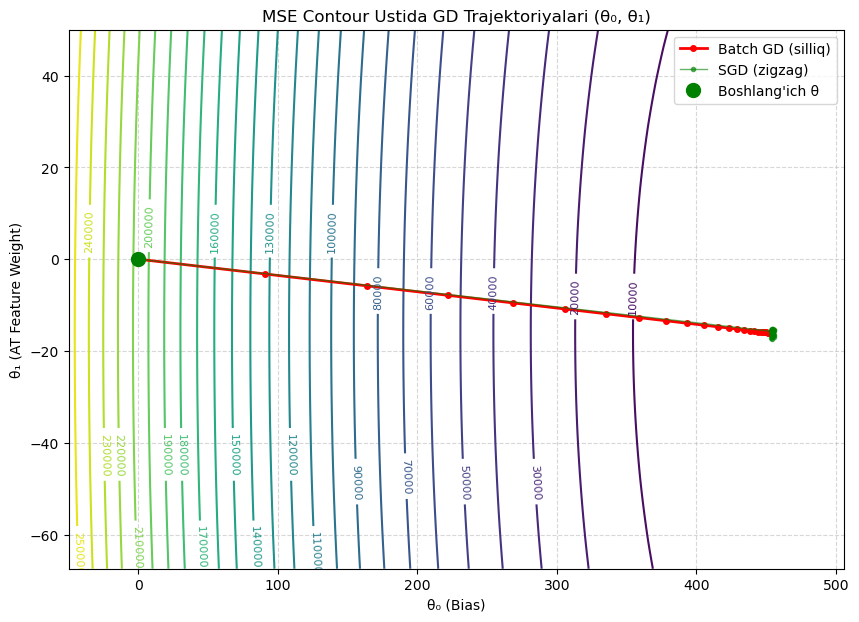

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Eng kuchli feature — AT (1-ustun) va y ma'lumotlarini ajratib olamiz
X_at = X_train_scaled[:, [0]]  # AT feature
y_tr = y_train.reshape(-1, 1)

# Model 1: Batch GD (batch_size=None)
bgd = LinearRegressionGD(lr=0.1, n_epochs=50, batch_size=None, seed=42)
bgd.fit(X_at, y_tr)

# Model 2: SGD (batch_size=1)
sgd = LinearRegressionGD(lr=0.01, n_epochs=50, batch_size=1, seed=42)
sgd.fit(X_at, y_tr)

# Contour panjarasini (Grid) tayyorlash
theta0_history_bgd = [t[0, 0] for t in bgd.theta_history]
theta1_history_bgd = [t[1, 0] for t in bgd.theta_history]

theta0_history_sgd = [t[0, 0] for t in sgd.theta_history]
theta1_history_sgd = [t[1, 0] for t in sgd.theta_history]

all_t0 = theta0_history_bgd + theta0_history_sgd
all_t1 = theta1_history_bgd + theta1_history_sgd

t0_vals = np.linspace(min(all_t0) - 50, max(all_t0) + 50, 100)
t1_vals = np.linspace(min(all_t1) - 50, max(all_t1) + 50, 100)
T0, T1 = np.meshgrid(t0_vals, t1_vals)

# Har bir (θ₀, θ₁) nuqta uchun MSE Loss hisoblash
X_b_at = np.c_[np.ones((X_at.shape[0], 1)), X_at]
Z = np.zeros(T0.shape)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        t = np.array([[T0[i, j]], [T1[i, j]]])
        Z[i, j] = np.mean((X_b_at @ t - y_tr) ** 2)

# Grafikni tasvirlash
plt.figure(figsize=(10, 7))
contours = plt.contour(T0, T1, Z, levels=30, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)

# BGD yo'lini chizish
plt.plot(theta0_history_bgd, theta1_history_bgd, 'ro-', linewidth=2, markersize=4, label='Batch GD (silliq)')
# SGD yo'lini chizish
plt.plot(theta0_history_sgd, theta1_history_sgd, 'g.-', alpha=0.6, linewidth=1, label='SGD (zigzag)')

# Boshlang'ich nuqtani belgilash
plt.plot(theta0_history_bgd[0], theta1_history_bgd[0], 'go', markersize=10, label='Boshlang\'ich θ')

plt.title('MSE Contour Ustida GD Trajektoriyalari (θ₀, θ₁)')
plt.xlabel('θ₀ (Bias)')
plt.ylabel('θ₁ (AT Feature Weight)')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

## 8-vazifa: Dataset tuzog'i
**Termodinamika yordami.** `AT` yolg'iz R² 0.90 beradi; `AT`–`V` corr 0.84. Scatter `AT` vs `PE` — biroz egri. 🔍 `AT²` ustunini qo'shing (yangi ustun `AT**2`, scale dan oldin): R² 0.930 → ? (kichik o'sish). Endi savol: ≈ 7 600 train qatorda **bitta epoch** batch GD ≈ 1 ta θ yangilanishi, SGD ≈ 7 700 ta. 4-vazifadagi vaqt jadvaliga qarab: 1 sekundda qaysi rejim ko'proq "foydali" yangilanish qiladi? Mini-batch=32 nega bu yerda eng yaxshi kelishuv?

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1. Feature Engineering: AT**2 ustunini qo'shish
X_poly = df[['AT', 'V', 'AP', 'RH']].copy()
X_poly['AT2'] = X_poly['AT'] ** 2

# Train/Test ajratish (test_size=0.2 qo'llanildi)
X_tr, X_te, y_tr, y_te = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

# Modelni o'qitish va R² ko'rsatkichini tekshirish
model_poly = LinearRegressionGD(lr=0.01, n_epochs=100, batch_size=32, seed=42)
model_poly.fit(X_tr_scaled, y_tr)

y_pred_poly = model_poly.predict(X_te_scaled)
print("Polynomial R² score:", r2_score(y_te, y_pred_poly))

Polynomial R² score: 0.9343345630677248


## 🔍 Tadqiqot (majburiy — kamida 2 tasi)
1. **Momentum**: `v = β·v − lr·∇; θ = θ + v` (β=0.9) ni sinfga qo'shing. Loss egri chiziqlarini oddiy GD bilan solishtiring — momentum nima uchun "tezlashtiradi", 3 gap. 7-vazifadagi contour da momentum yo'lini ham chizing.
2. **Early stopping**: train ning 20% ini validation qilib ajrating; validation loss 10 epoch ketma-ket yaxshilanmasa to'xtang, eng yaxshi θ ni qaytaring. Qaysi epoch da to'xtadi?
3. **Learning-rate schedule**: `lr_t = lr0 / (1 + k·t)` ni sinfga qo'shing (`decay=k`). SGD uchun schedule bilan va usiz loss ni solishtiring. Nega SGD ga schedule batch GD dan ko'ra ko'proq kerak?
4. **Ma'lumot hajmi va GD.** Train dan 500 / 2 000 / 7 600 qator olib (`np.random.choice`) batch GD va mini-batch(32) ni `n_epochs=20` da o'rgating: vaqt va test R² jadvali. Test R² qaysi hajmdan boshlab "to'yinadi"? Bu "ko'proq ma'lumot har doim yaxshi" degan fikrga nima deydi (🔍 learning curve — M3 4-qism, keyingi mavzu)?

In [ ]:
# TODO: tadqiqot

## ⭐ Bonus (+10)
`SGDRegressor` hujjatidan `eta0`, `learning_rate` (`'constant'`, `'invscaling'`, `'adaptive'`), `tol`, `n_iter_no_change` ni o'rganing. 2 xil sozlama bilan o'rgating va natijani sizning sinfingiz bilan solishtiring — qaysi parametr sizning qaysi g'oyangizga mos keladi?

## Topshirish

- Fayl nomi: `student_new_2_J2.ipynb` (shu fayl, to'ldirilgan). `Restart & Run All` qilingan, barcha grafiklar ko'rinib turibdi.
- Oxirgi katak — **Xulosa** (markdown, 6–10 gap): nimani o'rgandingiz, qaysi natija kutilmagan bo'ldi, nimani hali tushunmadingiz.
- Himoya: 5 daqiqa — istalgan katakdagi kodni tushuntirib berasiz.

## Baholash (100 ball + bonus)

| Mezon | Ball |
|---|---|
| `LinearRegressionGD` sinfi to'g'ri (3 rejim, loss_history, aralashtirish) | 25 |
| 3–8 vazifalar tajribalari va jadvallar | 25 |
| Savollarga tahliliy javoblar (7 ta) | 20 |
| Tadqiqot (2 ta) | 15 |
| Grafiklar + kod tozaligi | 15 |
| ⭐ Bonus | +10 |